# RT+ loop-distribution fitting notebook

Clean version with one consistent convention:

\[
y=[C_i,C_v,N_f,N_p,C_f,C_p]
\]

- `DF` data are treated as faulted loops only.
- `BF` data are treated as total loops, i.e. faulted + perfect/unfaulted loops.
- The paper-consistent radius relation is used:
\[
N_x = \frac{\pi b}{3\Omega_0} R_x^2 C_x,
\qquad
R_x = \sqrt{\frac{3\Omega_0 N_x}{\pi b C_x}}.
\]
- The distribution width is controlled by fitted parameters `k_f` and `k_p`, where:
\[
\mathrm{std}_f = k_f D_f, \qquad \mathrm{std}_p = k_p D_p.
\]


## 1. Imports


In [33]:
from pathlib import Path
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import lognorm
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.special import logsumexp

pi = np.pi
kB = 8.617333262e-5  # eV/K

%matplotlib inline


## 2. Data loader


In [34]:
STANDARD_ROOM_TEMPERATURE_C = 25.0


def parse_dataset_name(filename):
    # Parse filenames with format:
    #     <Temperature>-(B|D)F(-irr*)?
    stem = Path(filename).stem

    pattern = r"^(?P<temp>RT|\d+\.?\d*C?)-(?P<mode>[BD]F)(?:-(?P<irr>irr.*))?$"
    match = re.match(pattern, stem, flags=re.IGNORECASE)

    if match is None:
        raise ValueError(
            f"Filename does not match expected format '<Temperature>-(B|D)F(-irr*)?': {filename}"
        )

    temp_raw = match.group("temp").upper()
    mode = match.group("mode").upper()
    irr_tag = match.group("irr")

    if temp_raw == "RT":
        temperature_C = STANDARD_ROOM_TEMPERATURE_C
        temperature_label = "RT"
    else:
        temperature_C = float(temp_raw.replace("C", ""))
        temperature_label = f"{temperature_C:g}C"

    irradiated = irr_tag is not None

    return {
        "temperature_label": temperature_label,
        "temperature_C": temperature_C,
        "mode": mode,
        "irradiated": irradiated,
        "condition": "irradiated" if irradiated else "non-irradiated",
        "irr_tag": irr_tag.lower() if irr_tag is not None else None,
    }


def clean_numeric_columns(df):
    cleaned = {}

    for column in df.columns:
        values = pd.to_numeric(df[column], errors="coerce").dropna()
        values = values[np.isfinite(values)]
        values = values[values > 0]

        if values.empty:
            continue

        cleaned[column] = values.to_numpy(dtype=float)

    return cleaned


def load_data(data_dir="Data", pattern="*-[BD]F*.csv"):
    # Load loop-size datasets using filename format:
    #     <Temperature>-(B|D)F(-irr*)?
    data_dir = Path(data_dir)

    if not data_dir.exists():
        alt_data_dir = Path.cwd().parent / data_dir
        if alt_data_dir.exists():
            data_dir = alt_data_dir
        else:
            raise FileNotFoundError(f"Data directory not found: {data_dir}")

    paths = sorted(data_dir.glob(pattern))

    if len(paths) == 0:
        raise FileNotFoundError(
            f"No files found in {data_dir} matching pattern '{pattern}'"
        )

    datasets = {}
    rows = []

    for path in paths:
        metadata = parse_dataset_name(path.name)

        raw_df = pd.read_csv(path)
        values_by_column = clean_numeric_columns(raw_df)

        if len(values_by_column) == 0:
            print(f"Warning: no numeric data found in {path.name}")
            continue

        dataset_name = path.stem
        all_values = np.concatenate(list(values_by_column.values()))

        datasets[dataset_name] = {
            "path": path,
            "raw": raw_df,
            "values_by_column": values_by_column,
            "all_values": all_values,
            **metadata,
        }

        for column, values in values_by_column.items():
            for value in values:
                rows.append({
                    "dataset": dataset_name,
                    "temperature_label": metadata["temperature_label"],
                    "temperature_C": metadata["temperature_C"],
                    "mode": metadata["mode"],
                    "irradiated": metadata["irradiated"],
                    "condition": metadata["condition"],
                    "irr_tag": metadata["irr_tag"],
                    "column": column,
                    "size": value,
                    "source_file": path.name,
                })

    loop_data = pd.DataFrame(rows)

    return datasets, loop_data


## 3. Helper functions and paper-consistent geometry


In [35]:
def diffusion_coeff(D0, E, T_K):
    return D0 * np.exp(-E / (kB * T_K))


def coalescence_rate(P0, Ea, T_K):
    return P0 * np.exp(-Ea / (kB * T_K))


def logterminv(R, r0):
    # Safe inverse logarithm term.
    # Need 8R/r0 > 1 to avoid log <= 0.
    R_min = 1.01 * r0 / 8.0
    R_eff = np.maximum(R, R_min)
    return 1.0 / np.log(8.0 * R_eff / r0)


def j_x_L(Rx, Di, Ci, r0):
    # Interstitial flux to toroidal loop sink.
    return 2.0 * np.pi**2 * Rx * Di * Ci * logterminv(Rx, r0)


def compute_Rx(Nx, Cx, b, Omega0, eps_N=1e-300, eps_C=1e-300):
    # Paper-consistent radius calculation:
    #   N = (pi*b/(3*Omega0)) * R^2 * C
    #   R = sqrt(3*Omega0*N/(pi*b*C))
    Nx_eff = np.maximum(Nx, eps_N)
    Cx_eff = np.maximum(Cx, eps_C)

    return np.sqrt((3.0 * Omega0 * Nx_eff) / (np.pi * b * Cx_eff))


def loop_content_from_radius(Rx, Cx, b, Omega0):
    # Inverse of compute_Rx:
    #   Nx = (pi*b/(3*Omega0)) * R^2 * C
    geometry_factor = np.pi * b / (3.0 * Omega0)
    return geometry_factor * Rx**2 * Cx


## 4. ODE system


In [36]:
def ODE(t, y, params):
    # Six-variable RT+ model.
    # State:
    #     y = [Ci, Cv, Nf, Np, Cf, Cp]
    #
    # Ci = mobile interstitial concentration
    # Cv = mobile vacancy concentration
    # Nf = total interstitial content stored in faulted loops
    # Np = total interstitial content stored in perfect/unfaulted loops
    # Cf = faulted loop density
    # Cp = perfect/unfaulted loop density

    if not np.all(np.isfinite(y)):
        return np.zeros(6)

    # Variables
    Ci, Cv, Nf, Np, Cf, Cp = y

    # Parameters
    Di      = params["Di"]
    Dv      = params["Dv"]
    Rii     = params["Rii"]
    Zii     = params["Zii"]
    Puf     = params["Puf"]
    Pcs     = params["Pcs"]
    b       = params["b"]
    Omega0  = params["Omega0"]
    r0      = params["r0"]
    a       = params["a"]
    L = 1e-5 #100nm to cm
    # Optional source terms
    G0i = params.get("G0i", 0.0)
    G0v = params.get("G0v", 0.0)

    # Recombination constants; keep simple for now.
    Ziv_iK = params.get("Ziv_iK", 48.0)
    Ziv_vK = params.get("Ziv_vK", 48.0)

    # Clip only for evaluating the RHS.
    # Final states are still rejected in simulate_one_temperature if nonphysical.
    Ci_eff = max(Ci, 0.0)
    Cv_eff = max(Cv, 0.0)

    Nf_eff = max(Nf, 1e-300)
    Np_eff = max(Np, 1e-300)

    Cf_eff = max(Cf, 1e-300)
    Cp_eff = max(Cp, 1e-300)

    geometry_factor = (np.pi * b) / (3.0 * Omega0)

    # Average loop radii
    Rf = compute_Rx(Nf_eff, Cf_eff, b, Omega0)
    Rp = compute_Rx(Np_eff, Cp_eff, b, Omega0)

    # Interstitial fluxes to faulted and perfect loops
    jf = j_x_L(Rf, Di, Ci_eff, r0)
    jp = j_x_L(Rp, Di, Ci_eff, r0)

    # Interstitial-vacancy recombination coefficient
    kiv = (Omega0 / a**2) * (Ziv_iK * Di + Ziv_vK * Dv)

    df = np.zeros(6)

    # Mobile interstitials
    df[0] = (
        G0i
        - Rf * Cf_eff * jf
        - Rp * Cp_eff * jp
        - 2.0 * Zii * Di * Ci_eff**2
        - kiv * Ci_eff * Cv_eff 
        - 12/(L**2)
    )

    # Mobile vacancies
    df[1] = G0v - kiv * Ci_eff * Cv_eff - 12/(L**2)

    # Total interstitials stored in faulted loops
    # Paper-consistent unfaulting transfer term:
    # Puf * (pi*b/(3*Omega0)) * Rf^2 * Cf = Puf * Nf
    df[2] = (
        Rf * Cf_eff * jf
        - Puf * geometry_factor * Rf**2 * Cf_eff
    )

    # Total interstitials stored in perfect/unfaulted loops
    df[3] = (
        Rp * Cp_eff * jp
        + Puf * geometry_factor * Rf**2 * Cf_eff
    )

    # Faulted loop number density
    df[4] = (
        Rii * Di * Ci_eff**2
        - Puf * Cf_eff
    )

    # Perfect/unfaulted loop number density
    df[5] = (
        Puf * Cf_eff
        - Pcs * Cp_eff**2
    )

    if not np.all(np.isfinite(df)):
        return np.zeros(6)

    return df


## 5. Random physical initial condition


In [37]:
def loguniform(low, high, rng):
    return np.exp(rng.uniform(np.log(low), np.log(high)))


def make_random_y0(params, seed=None):
    # Generate a random but physically reasonable initial condition.
    #
    # State:
    #     y0 = [Ci0, Cv0, Nf0, Np0, Cf0, Cp0]
    #
    # Units:
    #     R in cm
    #     loop densities in cm^-3
    #     Ci, Cv in cm^-3

    rng = np.random.default_rng(seed)

    b = params["b"]
    Omega0 = params["Omega0"]

    # Mobile point-defect concentrations.
    # Paper values are closer to concentration units, not dimensionless fractions.
    Ci0 = loguniform(1e10, 1e18, rng)
    Cv0 = 0.0  # keep vacancies inactive for now

    # Loop densities, cm^-3
    Cf0 = loguniform(1e14, 1e18, rng)
    Cp0 = loguniform(1e12, 1e18, rng)

    # Initial loop radii, nm
    Rf0_nm = loguniform(0.5, 10.0, rng)
    Rp0_nm = loguniform(0.5, 20.0, rng)

    # Convert nm -> cm
    Rf0 = Rf0_nm * 1e-7
    Rp0 = Rp0_nm * 1e-7

    # Paper-consistent definition:
    # N = (pi*b/(3*Omega0))*R^2*C
    Nf0 = loop_content_from_radius(Rf0, Cf0, b, Omega0)
    Np0 = loop_content_from_radius(Rp0, Cp0, b, Omega0)

    y0 = np.array([Ci0, Cv0, Nf0, Np0, Cf0, Cp0], dtype=float)

    print("Random physical y0:")
    print(f"  Ci0 = {Ci0:.3e} cm^-3")
    print(f"  Cv0 = {Cv0:.3e} cm^-3")
    print(f"  Rf0 = {Rf0_nm:.3f} nm")
    print(f"  Rp0 = {Rp0_nm:.3f} nm")
    print(f"  Cf0 = {Cf0:.3e} cm^-3")
    print(f"  Cp0 = {Cp0:.3e} cm^-3")
    print(f"  Nf0 = {Nf0:.3e} cm^-3")
    print(f"  Np0 = {Np0:.3e} cm^-3")
    print(f"  len(y0) = {len(y0)}")

    return y0


## 6. Simulation wrapper


In [38]:
def simulate_one_temperature(T_C, theta, base_params, y0, t_end_s=3600):
    # Simulate RT+ model for one temperature.
    #
    # State:
    #     y = [Ci, Cv, Nf, Np, Cf, Cp]

    T_C = float(T_C)
    T_K = T_C + 273.15

    Eim = theta["Eim"]
    Evm = theta["Evm"]
    Ea = theta["Ea"]
    P0 = theta["P0"]
    Puf = theta["Puf_by_T"][T_C]

    params = base_params.copy()
    params["Di"] = diffusion_coeff(params["Di0"], Eim, T_K)
    params["Dv"] = diffusion_coeff(params["Dv0"], Evm, T_K)
    params["Pcs"] = coalescence_rate(P0, Ea, T_K)
    params["Puf"] = Puf

    sol = solve_ivp(
        fun=lambda t, y: ODE(t, y, params),
        t_span=(0.0, t_end_s),
        y0=y0,
        method="BDF",
        rtol=1e-6,
        atol=1e-12,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    y_final = sol.y[:, -1]
    Ci, Cv, Nf, Np, Cf, Cp = y_final

    # Reject nonphysical final loop states.
    if not np.all(np.isfinite(y_final)):
        raise RuntimeError("Non-finite solution.")

    if Nf <= 0 or Cf <= 0:
        raise RuntimeError("Faulted loop population became nonphysical.")

    if Np <= 0 or Cp <= 0:
        raise RuntimeError("Perfect/unfaulted loop population became nonphysical.")

    Rf = compute_Rx(Nf, Cf, params["b"], params["Omega0"])
    Rp = compute_Rx(Np, Cp, params["b"], params["Omega0"])

    if not np.isfinite(Rf) or not np.isfinite(Rp):
        raise RuntimeError("Nonphysical loop radius.")

    return {
        "y_final": y_final,
        "Rf": Rf,
        "Rp": Rp,
        "Cf": Cf,
        "Cp": Cp,
        "Di": params["Di"],
        "Dv": params["Dv"],
        "Pcs": params["Pcs"],
        "Puf": Puf,
    }


## 7. Lognormal distribution model


In [39]:
def lognormal_shape_from_mean_std(mean, std):
    # Convert physical mean and physical standard deviation
    # into scipy's lognormal shape parameter.

    mean = max(float(mean), 1e-30)
    std = max(float(std), 1e-30)

    return np.sqrt(np.log(1.0 + (std / mean)**2))


def lognormal_logpdf_from_mean_and_k(x, mean, k):
    # Lognormal log-PDF where:
    #     std = k * mean
    #
    # k controls the physical width of the distribution.

    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]

    mean = max(float(mean), 1e-30)
    k = max(float(k), 1e-8)

    std = k * mean
    sigma_logn = lognormal_shape_from_mean_std(mean, std)
    mu_logn = np.log(mean) - 0.5 * sigma_logn**2

    return lognorm.logpdf(x, s=sigma_logn, scale=np.exp(mu_logn))


def predicted_loop_logpdf(values_nm, mode, prediction, fit_theta, radius_unit_to_nm=1e7):
    # Predicted log-PDF for BF or DF data.
    #
    # DF = faulted loops only
    # BF = mixture of faulted + perfect/unfaulted loops

    values_nm = np.asarray(values_nm, dtype=float)
    values_nm = values_nm[np.isfinite(values_nm)]
    values_nm = values_nm[values_nm > 0]

    if len(values_nm) == 0:
        return np.array([])

    Rf_nm = prediction["Rf"] * radius_unit_to_nm
    Rp_nm = prediction["Rp"] * radius_unit_to_nm

    Df_nm = 2.0 * Rf_nm
    Dp_nm = 2.0 * Rp_nm

    Cf = max(float(prediction["Cf"]), 1e-30)
    Cp = max(float(prediction["Cp"]), 1e-30)

    k_f = fit_theta["k_f"]
    k_p = fit_theta["k_p"]

    logpdf_f = lognormal_logpdf_from_mean_and_k(
        x=values_nm,
        mean=Df_nm,
        k=k_f,
    )

    logpdf_p = lognormal_logpdf_from_mean_and_k(
        x=values_nm,
        mean=Dp_nm,
        k=k_p,
    )

    if mode == "DF":
        return logpdf_f

    if mode == "BF":
        wF = Cf / (Cf + Cp)
        wP = Cp / (Cf + Cp)

        return logsumexp(
            np.vstack([
                np.log(wF) + logpdf_f,
                np.log(wP) + logpdf_p,
            ]),
            axis=0,
        )

    raise ValueError(f"Unknown mode: {mode}")


def predicted_loop_pdf(x_nm, mode, prediction, fit_theta, radius_unit_to_nm=1e7):
    # PDF version used for plotting.

    return np.exp(
        predicted_loop_logpdf(
            values_nm=x_nm,
            mode=mode,
            prediction=prediction,
            fit_theta=fit_theta,
            radius_unit_to_nm=radius_unit_to_nm,
        )
    )


## 8. Fitting functions


In [40]:
def unpack_theta(theta_vec, temperatures):
    # theta = [
    #     Eim,
    #     Evm,
    #     Ea,
    #     log(P0),
    #     log(Puf_T1), ..., log(Puf_Tn),
    #     log(k_f),
    #     log(k_p)
    # ]

    Eim = theta_vec[0]
    Evm = theta_vec[1]
    Ea = theta_vec[2]
    P0 = np.exp(theta_vec[3])

    Puf_by_T = {}

    # Puf starts at index 4.
    idx = 4

    for T in temperatures:
        Puf_by_T[float(T)] = np.exp(theta_vec[idx])
        idx += 1

    k_f = np.exp(theta_vec[idx])
    k_p = np.exp(theta_vec[idx + 1])

    return {
        "Eim": Eim,
        "Evm": Evm,
        "Ea": Ea,
        "P0": P0,
        "Puf_by_T": Puf_by_T,
        "k_f": k_f,
        "k_p": k_p,
    }


def build_theta0_and_bounds(temperatures):
    # Build initial guesses and bounds.
    #
    # Units:
    #     Di0, Dv0 in cm^2/s
    #     P0 in cm^3/s

    Eim0 = 2.8
    Evm0 = 2.8
    Ea0 = 1.9

    # Paper value 0.6 um^3/s = 6e-13 cm^3/s.
    P0_0 = 6e-13

    Puf0_by_T = [1e-5 for _ in temperatures]

    # k = 0.5 means std = 0.5 * predicted mean diameter.
    k_f0 = 0.5
    k_p0 = 0.5

    theta0 = np.array(
        [Eim0, Evm0, Ea0, np.log(P0_0)]
        + [np.log(x) for x in Puf0_by_T]
        + [np.log(k_f0), np.log(k_p0)],
        dtype=float,
    )

    bounds = []

    bounds.append((0.1, 6.0))                       # Eim, eV
    bounds.append((0.1, 6.0))                       # Evm, eV
    bounds.append((0.1, 6.0))                       # Ea, eV

    bounds.append((np.log(1e-24), np.log(1e-8)))    # P0, cm^3/s

    for _ in temperatures:
        bounds.append((np.log(1e-10), np.log(1e-2))) # Puf(T), 1/s

    bounds.append((np.log(0.05), np.log(3.0)))      # k_f
    bounds.append((np.log(0.05), np.log(3.0)))      # k_p

    return theta0, bounds


def objective(
    theta_vec,
    loop_data,
    base_params,
    y0_initial,
    fit_temperatures,
    radius_unit_to_nm=1e7,
    t_end_s=3600,
):
    # Negative log-likelihood objective.
    #
    # Uses only irradiated data at fit_temperatures.

    theta = unpack_theta(theta_vec, fit_temperatures)

    total_nll = 0.0
    predictions = {}

    for T_C in fit_temperatures:
        try:
            predictions[float(T_C)] = simulate_one_temperature(
                T_C=float(T_C),
                theta=theta,
                base_params=base_params,
                y0=y0_initial,
                t_end_s=t_end_s,
            )
        except Exception:
            return 1e100

    data_to_fit = loop_data[
        (loop_data["irradiated"] == True) &
        (loop_data["temperature_C"].isin(fit_temperatures))
    ].copy()

    if len(data_to_fit) == 0:
        return 1e100

    for (T_C, mode), group in data_to_fit.groupby(["temperature_C", "mode"]):
        values_nm = group["size"].to_numpy(dtype=float)

        logpdf = predicted_loop_logpdf(
            values_nm=values_nm,
            mode=mode,
            prediction=predictions[float(T_C)],
            fit_theta=theta,
            radius_unit_to_nm=radius_unit_to_nm,
        )

        if len(logpdf) == 0:
            return 1e100

        if not np.all(np.isfinite(logpdf)):
            return 1e100

        # Mean NLL so one dataset does not dominate only because it has more loops.
        total_nll += -np.mean(logpdf)

    if not np.isfinite(total_nll):
        return 1e100

    return total_nll


## 9. Plotting and diagnostics


In [41]:
def plot_model_vs_data(
    values_nm,
    mode,
    prediction,
    fit_theta,
    radius_unit_to_nm=1e7,
    title="",
    bins=20,
):
    values_nm = np.asarray(values_nm, dtype=float)
    values_nm = values_nm[np.isfinite(values_nm)]
    values_nm = values_nm[values_nm > 0]

    if len(values_nm) == 0:
        print(f"No valid data for {title}")
        return

    Rf_nm = prediction["Rf"] * radius_unit_to_nm
    Rp_nm = prediction["Rp"] * radius_unit_to_nm

    Df_nm = 2.0 * Rf_nm
    Dp_nm = 2.0 * Rp_nm

    x_max = max(values_nm.max() * 1.2, Df_nm * 1.5, Dp_nm * 1.5)
    x = np.linspace(1e-9, x_max, 500)

    pdf_model = predicted_loop_pdf(
        x_nm=x,
        mode=mode,
        prediction=prediction,
        fit_theta=fit_theta,
        radius_unit_to_nm=radius_unit_to_nm,
    )

    plt.figure(figsize=(7, 5))

    plt.hist(
        values_nm,
        bins=bins,
        density=True,
        alpha=0.65,
        edgecolor="black",
        label="Experimental data",
    )

    plt.plot(
        x,
        pdf_model,
        linewidth=2.5,
        label="RT+ fitted distribution",
    )

    plt.axvline(
        Df_nm,
        linestyle="--",
        linewidth=1.5,
        label=f"Faulted diameter = {Df_nm:.2f} nm",
    )

    if mode == "BF":
        plt.axvline(
            Dp_nm,
            linestyle=":",
            linewidth=1.5,
            label=f"Perfect diameter = {Dp_nm:.2f} nm",
        )

    plt.title(title)
    plt.xlabel("Loop diameter (nm)")
    plt.ylabel("Probability density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_all_model_vs_data(
    loop_data,
    fit_theta,
    base_params,
    y0_initial,
    fit_temperatures,
    radius_unit_to_nm=1e7,
    t_end_s=3600,
    bins=20,
):
    predictions = {}

    for T_C in fit_temperatures:
        predictions[float(T_C)] = simulate_one_temperature(
            T_C=float(T_C),
            theta=fit_theta,
            base_params=base_params,
            y0=y0_initial,
            t_end_s=t_end_s,
        )

    data_to_plot = loop_data[
        (loop_data["irradiated"] == True) &
        (loop_data["temperature_C"].isin(fit_temperatures))
    ].copy()

    for (T_C, mode), group in data_to_plot.groupby(["temperature_C", "mode"]):
        T_C = float(T_C)
        values_nm = group["size"].to_numpy(dtype=float)

        title = f"{T_C:g} °C - {mode} - irradiated"

        plot_model_vs_data(
            values_nm=values_nm,
            mode=mode,
            prediction=predictions[T_C],
            fit_theta=fit_theta,
            radius_unit_to_nm=radius_unit_to_nm,
            title=title,
            bins=bins,
        )

    return predictions


def print_prediction_diagnostics(predictions, radius_unit_to_nm=1e7):
    for T_C, pred in predictions.items():
        Ci, Cv, Nf, Np, Cf, Cp = pred["y_final"]

        Df_nm = 2.0 * pred["Rf"] * radius_unit_to_nm
        Dp_nm = 2.0 * pred["Rp"] * radius_unit_to_nm

        print(f"\\nT = {T_C:g} °C")
        print(f"  Ci = {Ci:.3e}")
        print(f"  Cv = {Cv:.3e}")
        print(f"  Nf = {Nf:.3e}")
        print(f"  Np = {Np:.3e}")
        print(f"  Cf = {Cf:.3e} cm^-3")
        print(f"  Cp = {Cp:.3e} cm^-3")
        print(f"  Df = {Df_nm:.6e} nm")
        print(f"  Dp = {Dp_nm:.6e} nm")
        print(f"  perfect fraction = {Cp / (Cf + Cp + 1e-300):.3e}")


## 10. Load data


In [42]:
datasets, loop_data = load_data(data_dir="Data")

print(loop_data[[
    "dataset",
    "temperature_label",
    "temperature_C",
    "mode",
    "irradiated",
    "source_file",
]].drop_duplicates().sort_values(["temperature_C", "mode", "irradiated"]).to_string(index=False))

irr_data = loop_data[loop_data["irradiated"]]
non_irr_data = loop_data[~loop_data["irradiated"]]

print("\\nNumber of data points:", len(loop_data))
print("Irradiated data points:", len(irr_data))
print("Non-irradiated data points:", len(non_irr_data))


    dataset temperature_label  temperature_C mode  irradiated     source_file
      RT-BF                RT           25.0   BF       False       RT-BF.csv
  RT-BF-irr                RT           25.0   BF        True   RT-BF-irr.csv
      RT-DF                RT           25.0   DF       False       RT-DF.csv
  RT-DF-irr                RT           25.0   DF        True   RT-DF-irr.csv
     900-BF              900C          900.0   BF       False      900-BF.csv
 900-BF-irr              900C          900.0   BF        True  900-BF-irr.csv
     900-DF              900C          900.0   DF       False      900-DF.csv
 900-DF-irr              900C          900.0   DF        True  900-DF-irr.csv
1100-BF-irr             1100C         1100.0   BF        True 1100-BF-irr.csv
1100-DF-irr             1100C         1100.0   DF        True 1100-DF-irr.csv
\nNumber of data points: 12694
Irradiated data points: 10171
Non-irradiated data points: 2523


## 11. Constants and base parameters


In [43]:
# -----------------------------
# Lattice / geometry constants
# -----------------------------

a = 5.41e-8  # cm
b = (a / 2.0) * np.sqrt(2.0)
Omega0 = (a**3) / 4.0
r0 = 2.0 * a

Zii = 12.0
Rii = (np.sqrt(3.0) / 2.0) * a


# -----------------------------
# Base parameters
# -----------------------------
# Unit conversion reminder:
#   1 um^2/s = 1e-8 cm^2/s
#   1 um^3/s = 1e-12 cm^3/s
#
# If using the paper value D0 = 1e6 um^2/s:
#   D0 = 1e6 * 1e-8 = 1e-2 cm^2/s

base_params = {
    "a": a,
    "b": b,
    "Omega0": Omega0,
    "r0": r0,

    "Di0": 1e-2,  # cm^2/s
    "Dv0": 1e-2,  # cm^2/s, placeholder

    "Rii": Rii,
    "Zii": Zii,

    "G0i": 0.0,
    "G0v": 0.0,
}


## 12. Choose fitting temperatures


In [44]:
available_temperatures = sorted(
    float(T) for T in loop_data[loop_data["irradiated"]]["temperature_C"].dropna().unique()
)

print("Available irradiated temperatures:", available_temperatures)

# Exclude RT / 25 C by default for annealing-type fitting.
FIT_TEMPERATURES = [T for T in available_temperatures if T >= 900.0]

# If you really want to include RT, replace the line above with:
# FIT_TEMPERATURES = available_temperatures

print("Fit temperatures:", FIT_TEMPERATURES)

if len(FIT_TEMPERATURES) == 0:
    raise ValueError("No fitting temperatures selected. Check file names and irradiation flags.")


Available irradiated temperatures: [25.0, 900.0, 1100.0]
Fit temperatures: [900.0, 1100.0]


## 13. Single-start fit


In [45]:
# Random physical initial condition
y0_initial = make_random_y0(base_params, seed=10)

theta0, bounds = build_theta0_and_bounds(FIT_TEMPERATURES)

expected_length = 4 + len(FIT_TEMPERATURES) + 2
print("len(theta0) =", len(theta0))
print("expected length =", expected_length)
print("len(bounds) =", len(bounds))

assert len(theta0) == expected_length
assert len(bounds) == expected_length

result = minimize(
    objective,
    theta0,
    args=(loop_data, base_params, y0_initial, FIT_TEMPERATURES),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "maxiter": 5000,
        "ftol": 1e-9,
        "gtol": 1e-6,
    },
)

fit_theta = unpack_theta(result.x, FIT_TEMPERATURES)

print("Fit success:", result.success)
print("Message:", result.message)
print("Final objective:", result.fun)
print("Fit parameters:")
print(fit_theta)

assert 0.05 <= fit_theta["k_f"] <= 3.0
assert 0.05 <= fit_theta["k_p"] <= 3.0


Random physical y0:
  Ci0 = 4.446e+17 cm^-3
  Cv0 = 0.000e+00 cm^-3
  Rf0 = 0.782 nm
  Rp0 = 3.315 nm
  Cf0 = 6.772e+14 cm^-3
  Cp0 = 9.347e+16 cm^-3
  Nf0 = 4.191e+15 cm^-3
  Np0 = 1.040e+19 cm^-3
  len(y0) = 6
len(theta0) = 8
expected length = 8
len(bounds) = 8
Fit success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final objective: 11.143209509778774
Fit parameters:
{'Eim': np.float64(2.799410075983263), 'Evm': np.float64(2.8), 'Ea': np.float64(6.0), 'P0': np.float64(2.3697866257632973e-13), 'Puf_by_T': {900.0: np.float64(9.970810493461366e-06), 1100.0: np.float64(9.865330321412289e-06)}, 'k_f': np.float64(0.964268830930695), 'k_p': np.float64(0.7874092148138017)}


## 14. Plot fitted distributions


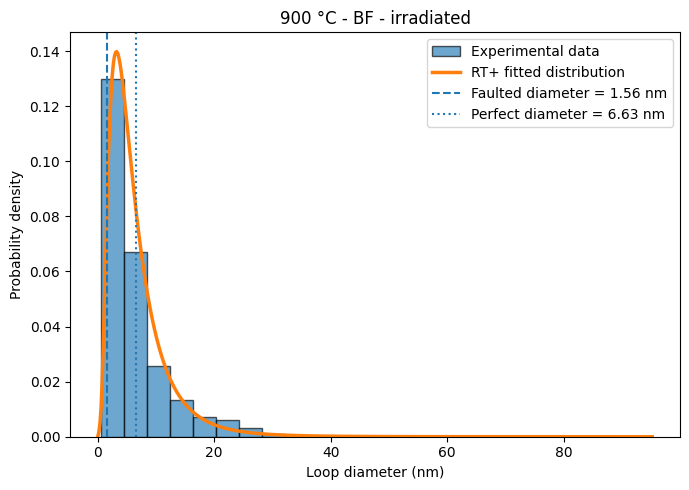

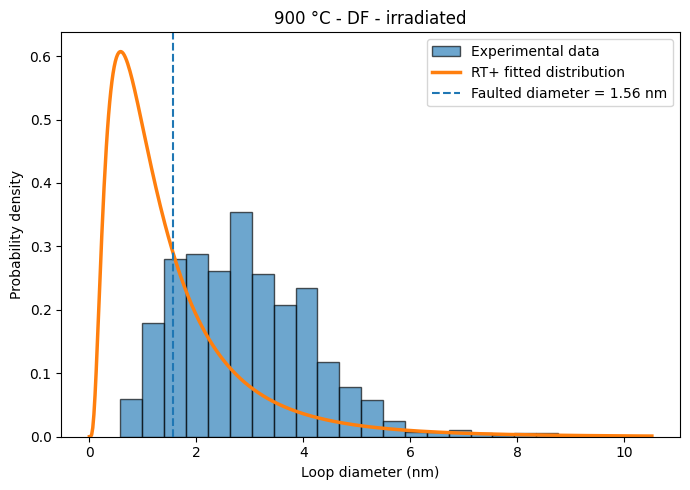

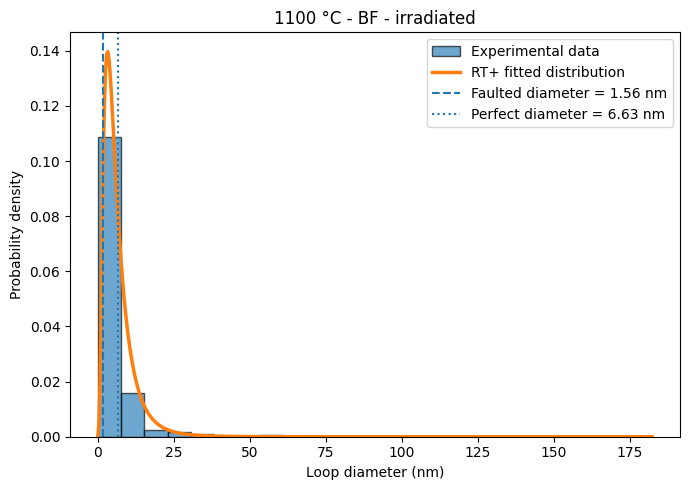

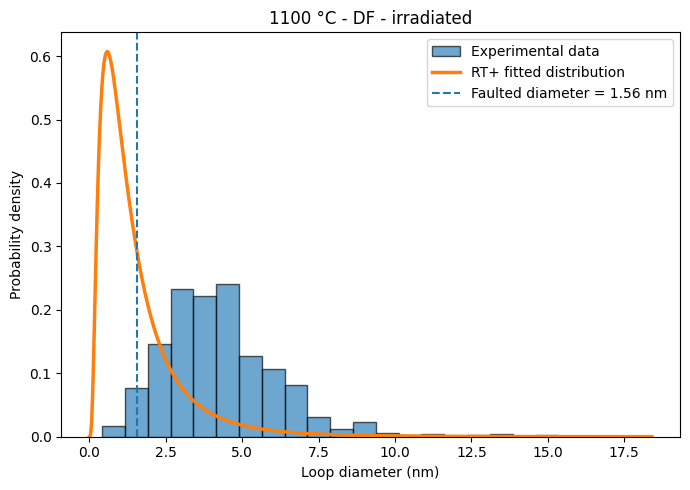

\nT = 900 °C
  Ci = -4.309e+14
  Cv = -4.320e+14
  Nf = 4.043e+15
  Np = 1.040e+19
  Cf = 6.533e+14 cm^-3
  Cp = 9.349e+16 cm^-3
  Df = 1.563941e+00 nm
  Dp = 6.629662e+00 nm
  perfect fraction = 9.931e-01
\nT = 1100 °C
  Ci = -4.318e+14
  Cv = -4.320e+14
  Nf = 4.044e+15
  Np = 1.040e+19
  Cf = 6.536e+14 cm^-3
  Cp = 9.349e+16 cm^-3
  Df = 1.563941e+00 nm
  Dp = 6.629670e+00 nm
  perfect fraction = 9.931e-01


In [46]:
predictions = plot_all_model_vs_data(
    loop_data=loop_data,
    fit_theta=fit_theta,
    base_params=base_params,
    y0_initial=y0_initial,
    fit_temperatures=FIT_TEMPERATURES,
    radius_unit_to_nm=1e7,
    t_end_s=3600,
    bins=20,
)

print_prediction_diagnostics(predictions)


## 15. Optional: multi-start fitting


In [47]:
def run_fit_for_seed(seed, loop_data, base_params, fit_temperatures):
    y0_seed = make_random_y0(base_params, seed=seed)
    theta0, bounds = build_theta0_and_bounds(fit_temperatures)

    res = minimize(
        objective,
        theta0,
        args=(loop_data, base_params, y0_seed, fit_temperatures),
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 5000,
            "ftol": 1e-9,
            "gtol": 1e-6,
        },
    )

    theta = unpack_theta(res.x, fit_temperatures)

    return {
        "seed": seed,
        "result": res,
        "fit_theta": theta,
        "y0": y0_seed,
        "objective": res.fun,
        "success": res.success,
    }


def run_multistart(seeds, loop_data, base_params, fit_temperatures):
    runs = []

    for seed in seeds:
        print(f"\\nRunning seed {seed}...")
        run = run_fit_for_seed(seed, loop_data, base_params, fit_temperatures)
        print(f"  success = {run['success']}")
        print(f"  objective = {run['objective']:.6g}")
        runs.append(run)

    runs_sorted = sorted(runs, key=lambda r: r["objective"])
    return runs_sorted


# Uncomment to run multi-start:
seeds = [1, 2, 3, 4, 5, 10, 20, 30]
runs = run_multistart(seeds, loop_data, base_params, FIT_TEMPERATURES)
best = runs[0]
fit_theta = best["fit_theta"]
y0_initial = best["y0"]
print("Best seed:", best["seed"])
print("Best objective:", best["objective"])
print(fit_theta)


\nRunning seed 1...
Random physical y0:
  Ci0 = 1.243e+14 cm^-3
  Cv0 = 0.000e+00 cm^-3
  Rf0 = 8.574 nm
  Rp0 = 1.580 nm
  Cf0 = 6.337e+17 cm^-3
  Cp0 = 7.328e+12 cm^-3
  Nf0 = 4.714e+20 cm^-3
  Np0 = 1.850e+14 cm^-3
  len(y0) = 6
  success = True
  objective = 11.2157
\nRunning seed 2...
Random physical y0:
  Ci0 = 1.239e+12 cm^-3
  Cv0 = 0.000e+00 cm^-3
  Rf0 = 0.658 nm
  Rp0 = 4.575 nm
  Cf0 = 1.563e+15 cm^-3
  Cp0 = 7.680e+16 cm^-3
  Nf0 = 6.859e+15 cm^-3
  Np0 = 1.627e+19 cm^-3
  len(y0) = 6
  success = True
  objective = 11.822
\nRunning seed 3...
Random physical y0:
  Ci0 = 4.844e+10 cm^-3
  Cv0 = 0.000e+00 cm^-3
  Rf0 = 2.860 nm
  Rp0 = 0.708 nm
  Cf0 = 8.856e+14 cm^-3
  Cp0 = 6.422e+16 cm^-3
  Nf0 = 7.331e+16 cm^-3
  Np0 = 3.254e+17 cm^-3
  len(y0) = 6
  success = True
  objective = 9.48575
\nRunning seed 4...
Random physical y0:
  Ci0 = 3.503e+17 cm^-3
  Cv0 = 0.000e+00 cm^-3
  Rf0 = 0.637 nm
  Rp0 = 4.699 nm
  Cf0 = 1.110e+16 cm^-3
  Cp0 = 7.202e+17 cm^-3
  Nf0 = 4.558e+16 

## 16. Optional: plot best multi-start result


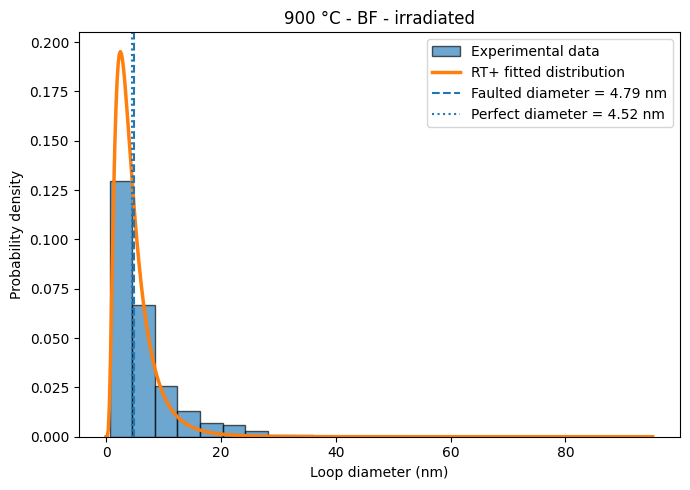

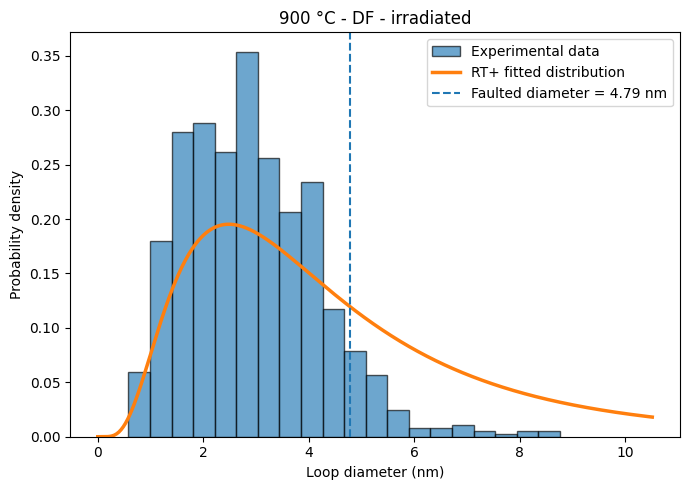

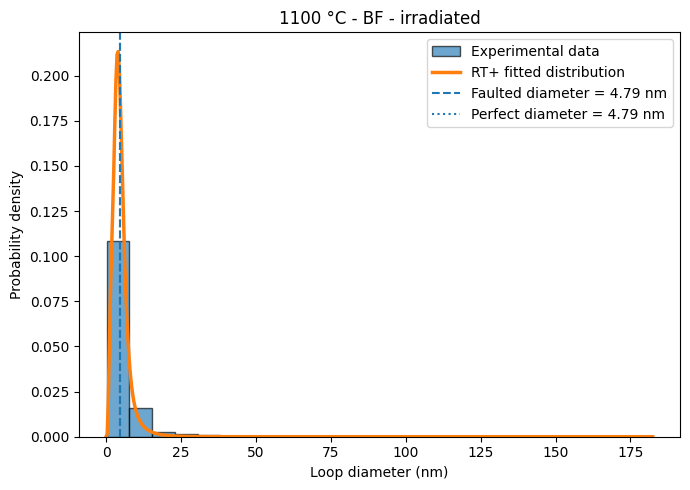

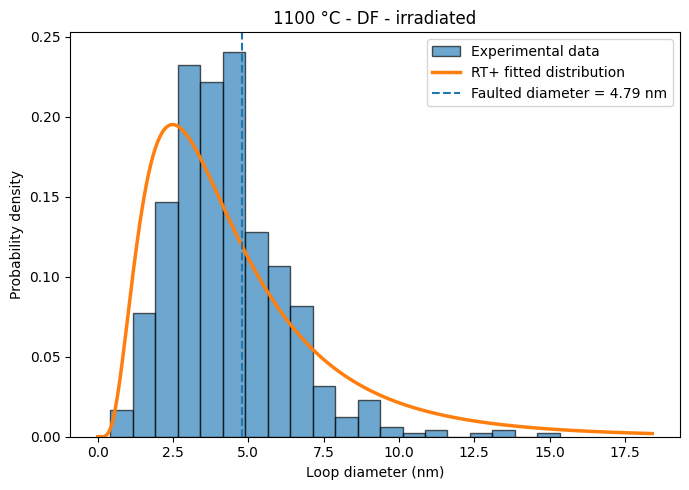

\nT = 900 °C
  Ci = -4.309e+14
  Cv = -4.320e+14
  Nf = 4.051e+17
  Np = 2.784e+14
  Cf = 6.992e+15 cm^-3
  Cp = 5.377e+12 cm^-3
  Df = 4.785520e+00 nm
  Dp = 4.524019e+00 nm
  perfect fraction = 7.684e-04
\nT = 1100 °C
  Ci = -4.318e+14
  Cv = -4.320e+14
  Nf = 2.299e+17
  Np = 1.755e+17
  Cf = 3.968e+15 cm^-3
  Cp = 3.029e+15 cm^-3
  Df = 4.785520e+00 nm
  Dp = 4.785069e+00 nm
  perfect fraction = 4.329e-01


In [48]:
# Uncomment after running multi-start:
predictions = plot_all_model_vs_data(
     loop_data=loop_data,
     fit_theta=fit_theta,
     base_params=base_params,
     y0_initial=y0_initial,
     fit_temperatures=FIT_TEMPERATURES,
     radius_unit_to_nm=1e7,
     t_end_s=3600,
     bins=20,
)
print_prediction_diagnostics(predictions)
